# Baldur's Gate Dark Alliance 2 statistics & functions

In [2]:
import random
import numpy as np
import pandas as pd
import statistics as stats

## Raw weapon damage

In [4]:
# analysis of non-magical weapon damage without modifiers
def noMagic_noMod_weapon_dmg(min_damage, max_damage, trials= 10000):
    '''
    Calculate damage metrics for non-magical weapons with no modifiers
    for early game optimization of damage.
    Args:
        min_damage: minimum possible damage
        max_damage: maximum possible damage
        trials: default 10,000 iterations of the loop
    Returns:
        pd.DataFrame() containing range, average, median and standard deviation metrics
    '''
    damage_rolls = [random.randrange(min_damage, max_damage +1) for _ in range(trials)]
    weapon_metrics = {
        'minimum': min(damage_rolls),
        'maximum': max(damage_rolls),
        'range': max_damage - min_damage,
        'average': stats.mean(damage_rolls),
        'median': stats.median(damage_rolls),
        'std_dev': round(stats.stdev(damage_rolls), 2)
    }
    return pd.DataFrame(weapon_metrics, index= [0])

With this function, we can see the raw (i.e., not factoring gems) stats of weapons to easily compare the effectiveness of weapons of different ranges and identify those with the highest average. Example below from my Borador playthrough.
<div>
    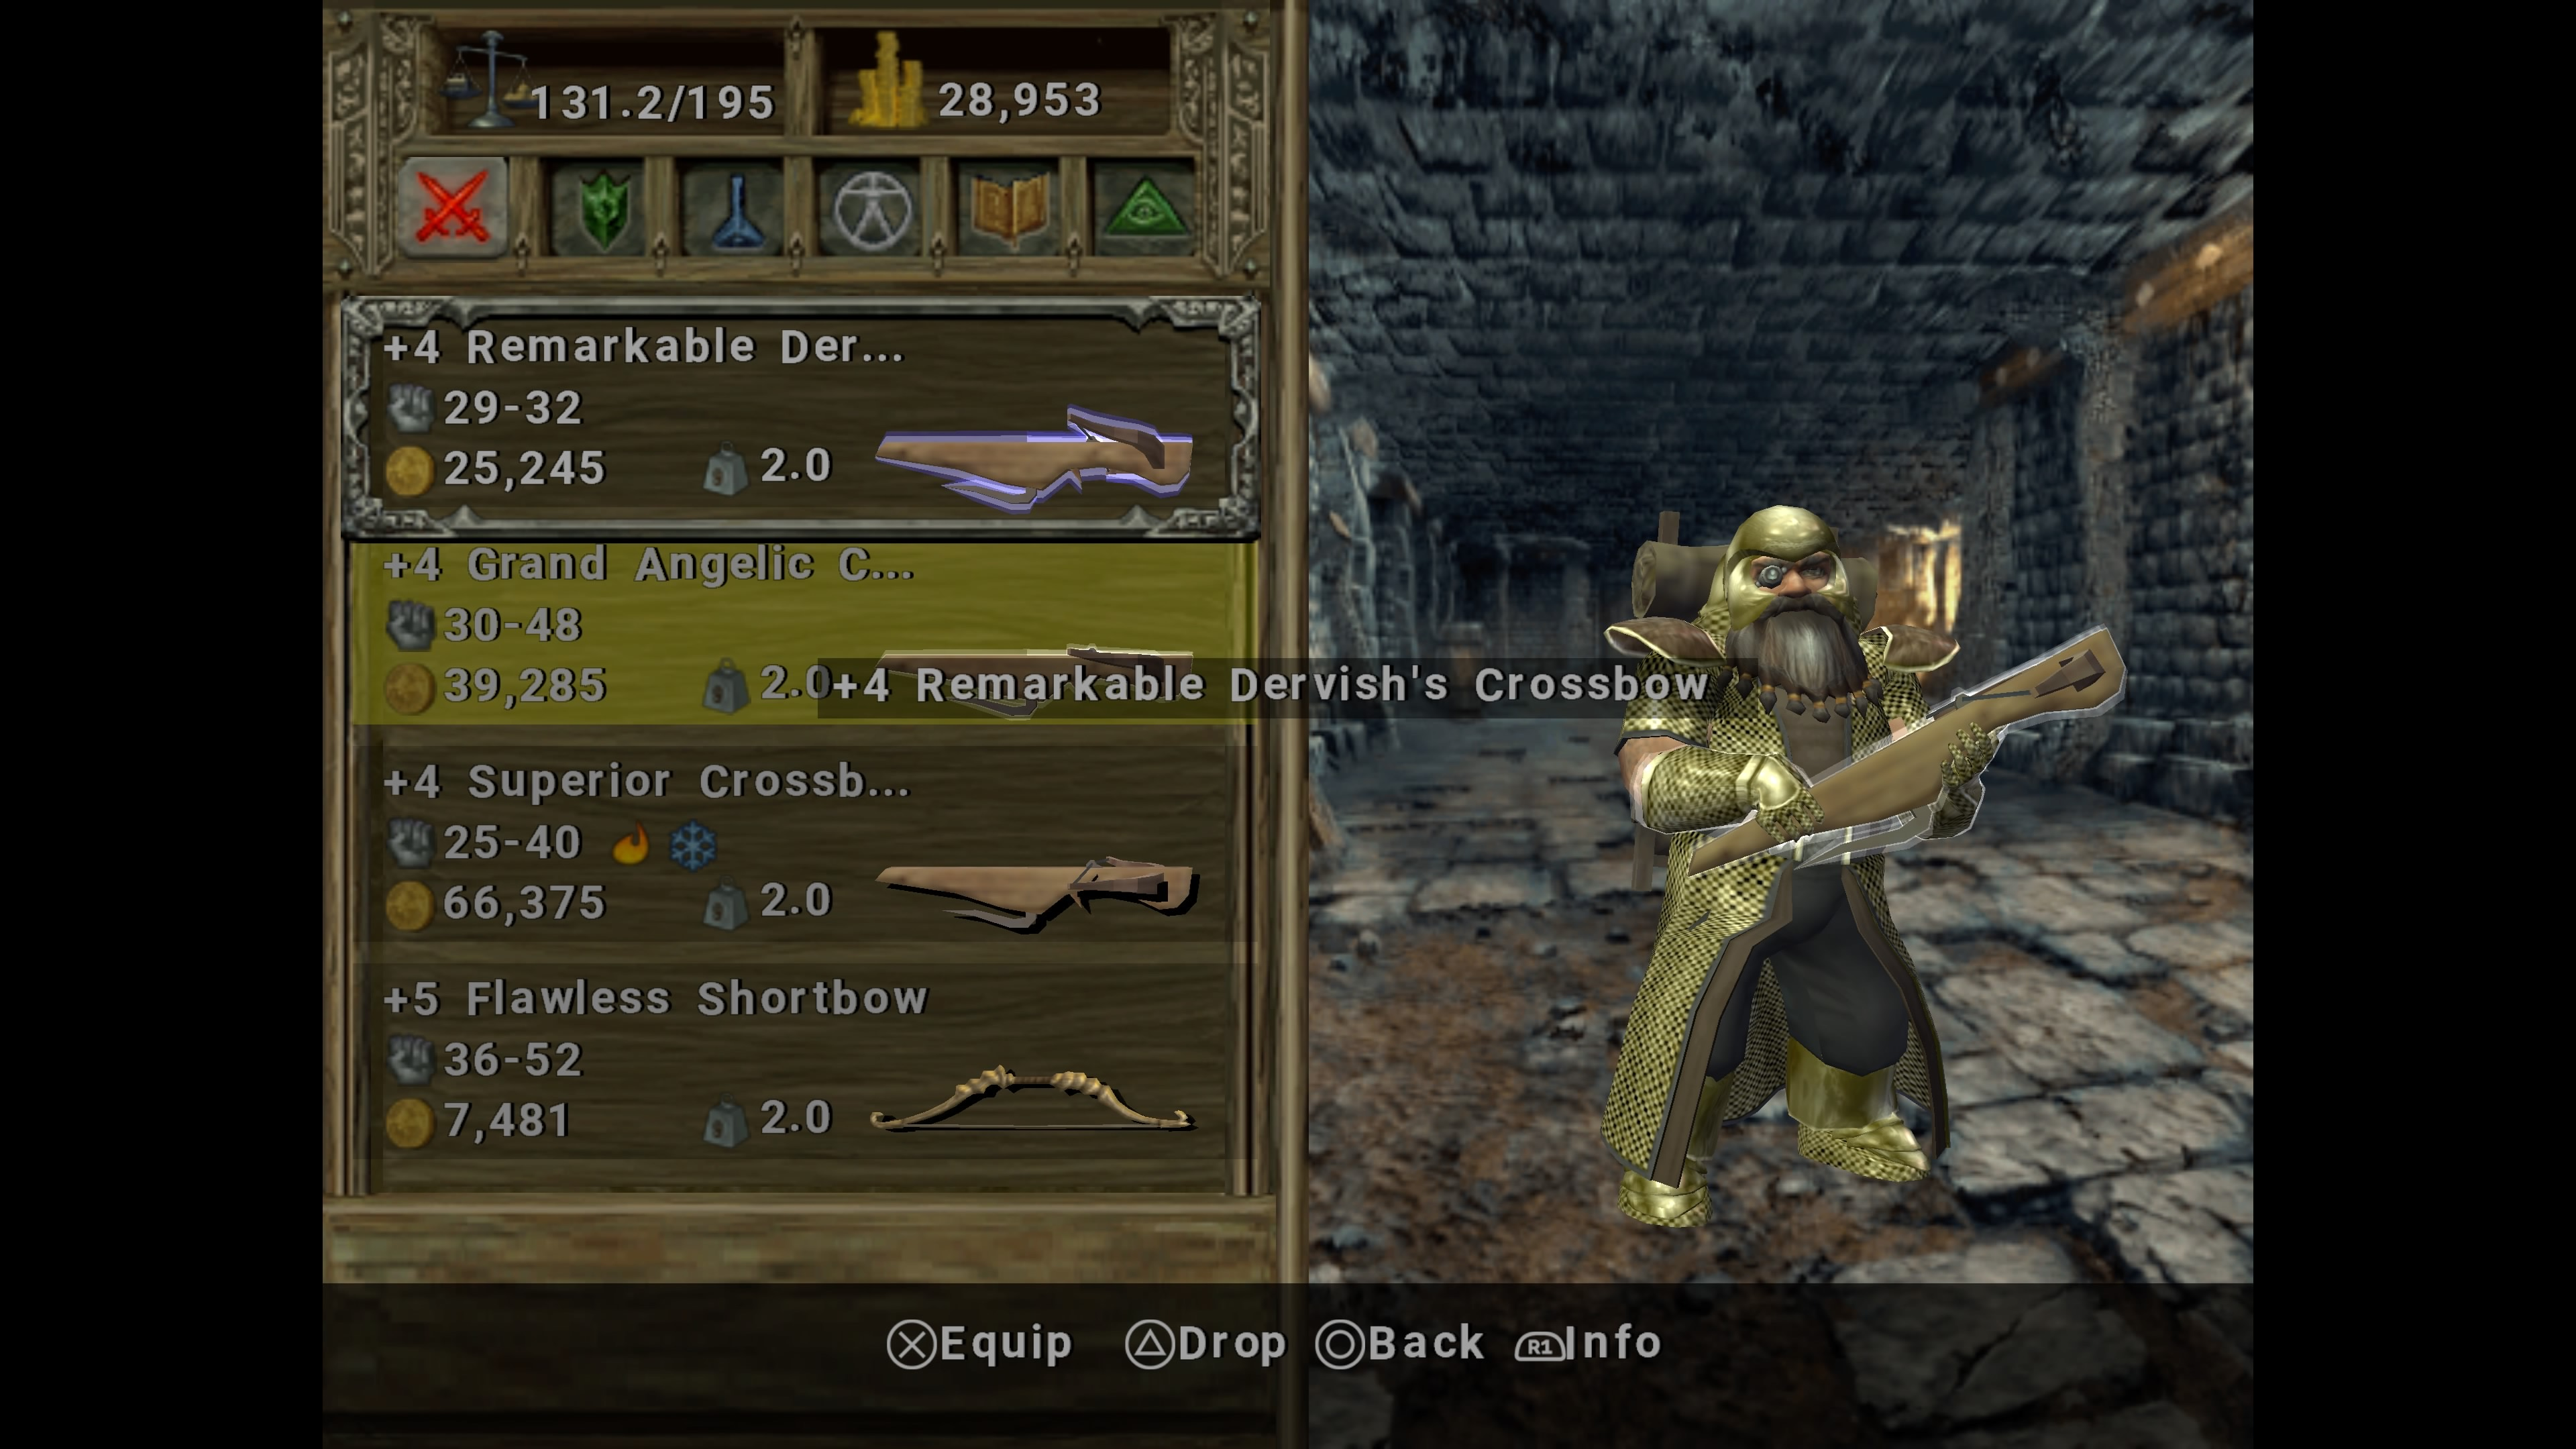
</div>

In [6]:
# +4 Remarkable Dervish's Crossbow
noMagic_noMod_weapon_dmg(29,32)

,minimum,maximum,range,average,median,std_dev
0,29,32,3,30.4922,30.0,1.12


In [7]:
# +4 Grand Angelic Crossbow
noMagic_noMod_weapon_dmg(30,48)

,minimum,maximum,range,average,median,std_dev
0,30,48,18,38.8506,39.0,5.48


In [8]:
# +4 Superior Crossbow of Cold Fire
noMagic_noMod_weapon_dmg(25,40)

,minimum,maximum,range,average,median,std_dev
0,25,40,15,32.5365,33.0,4.62


In [9]:
# +5 Flawless Shortbow
noMagic_noMod_weapon_dmg(36,52)

,minimum,maximum,range,average,median,std_dev
0,36,52,16,44.1223,44.0,4.86


As we can see here, the +5 shortbow is unsurprisingly the highest average raw average damage output. However, the +4 superior crossbow is on average more effective than the +4 remarkable Dervish's crossbow despite its lower minimum damage and broader range of possible rolls.

## Ysuran's spells analysis

Ysuran's abilities are harder to compare side-by-side as they have different attributes but they can still be boiled to core elements:
- is the spell a one-off or is held?
- does the damage apply once or multiple times?
- does the spell apply damage and healing?
- does the spell apply a debuff to enemies?

### Shadow Spray

As can be seen below, Shadow Spray is 
- a one-off spell,
- inflicting at rank 5 20-60 damage per ribbon,
- with 5 ribbons because the spell was upgraded to rank 5.

<div>
    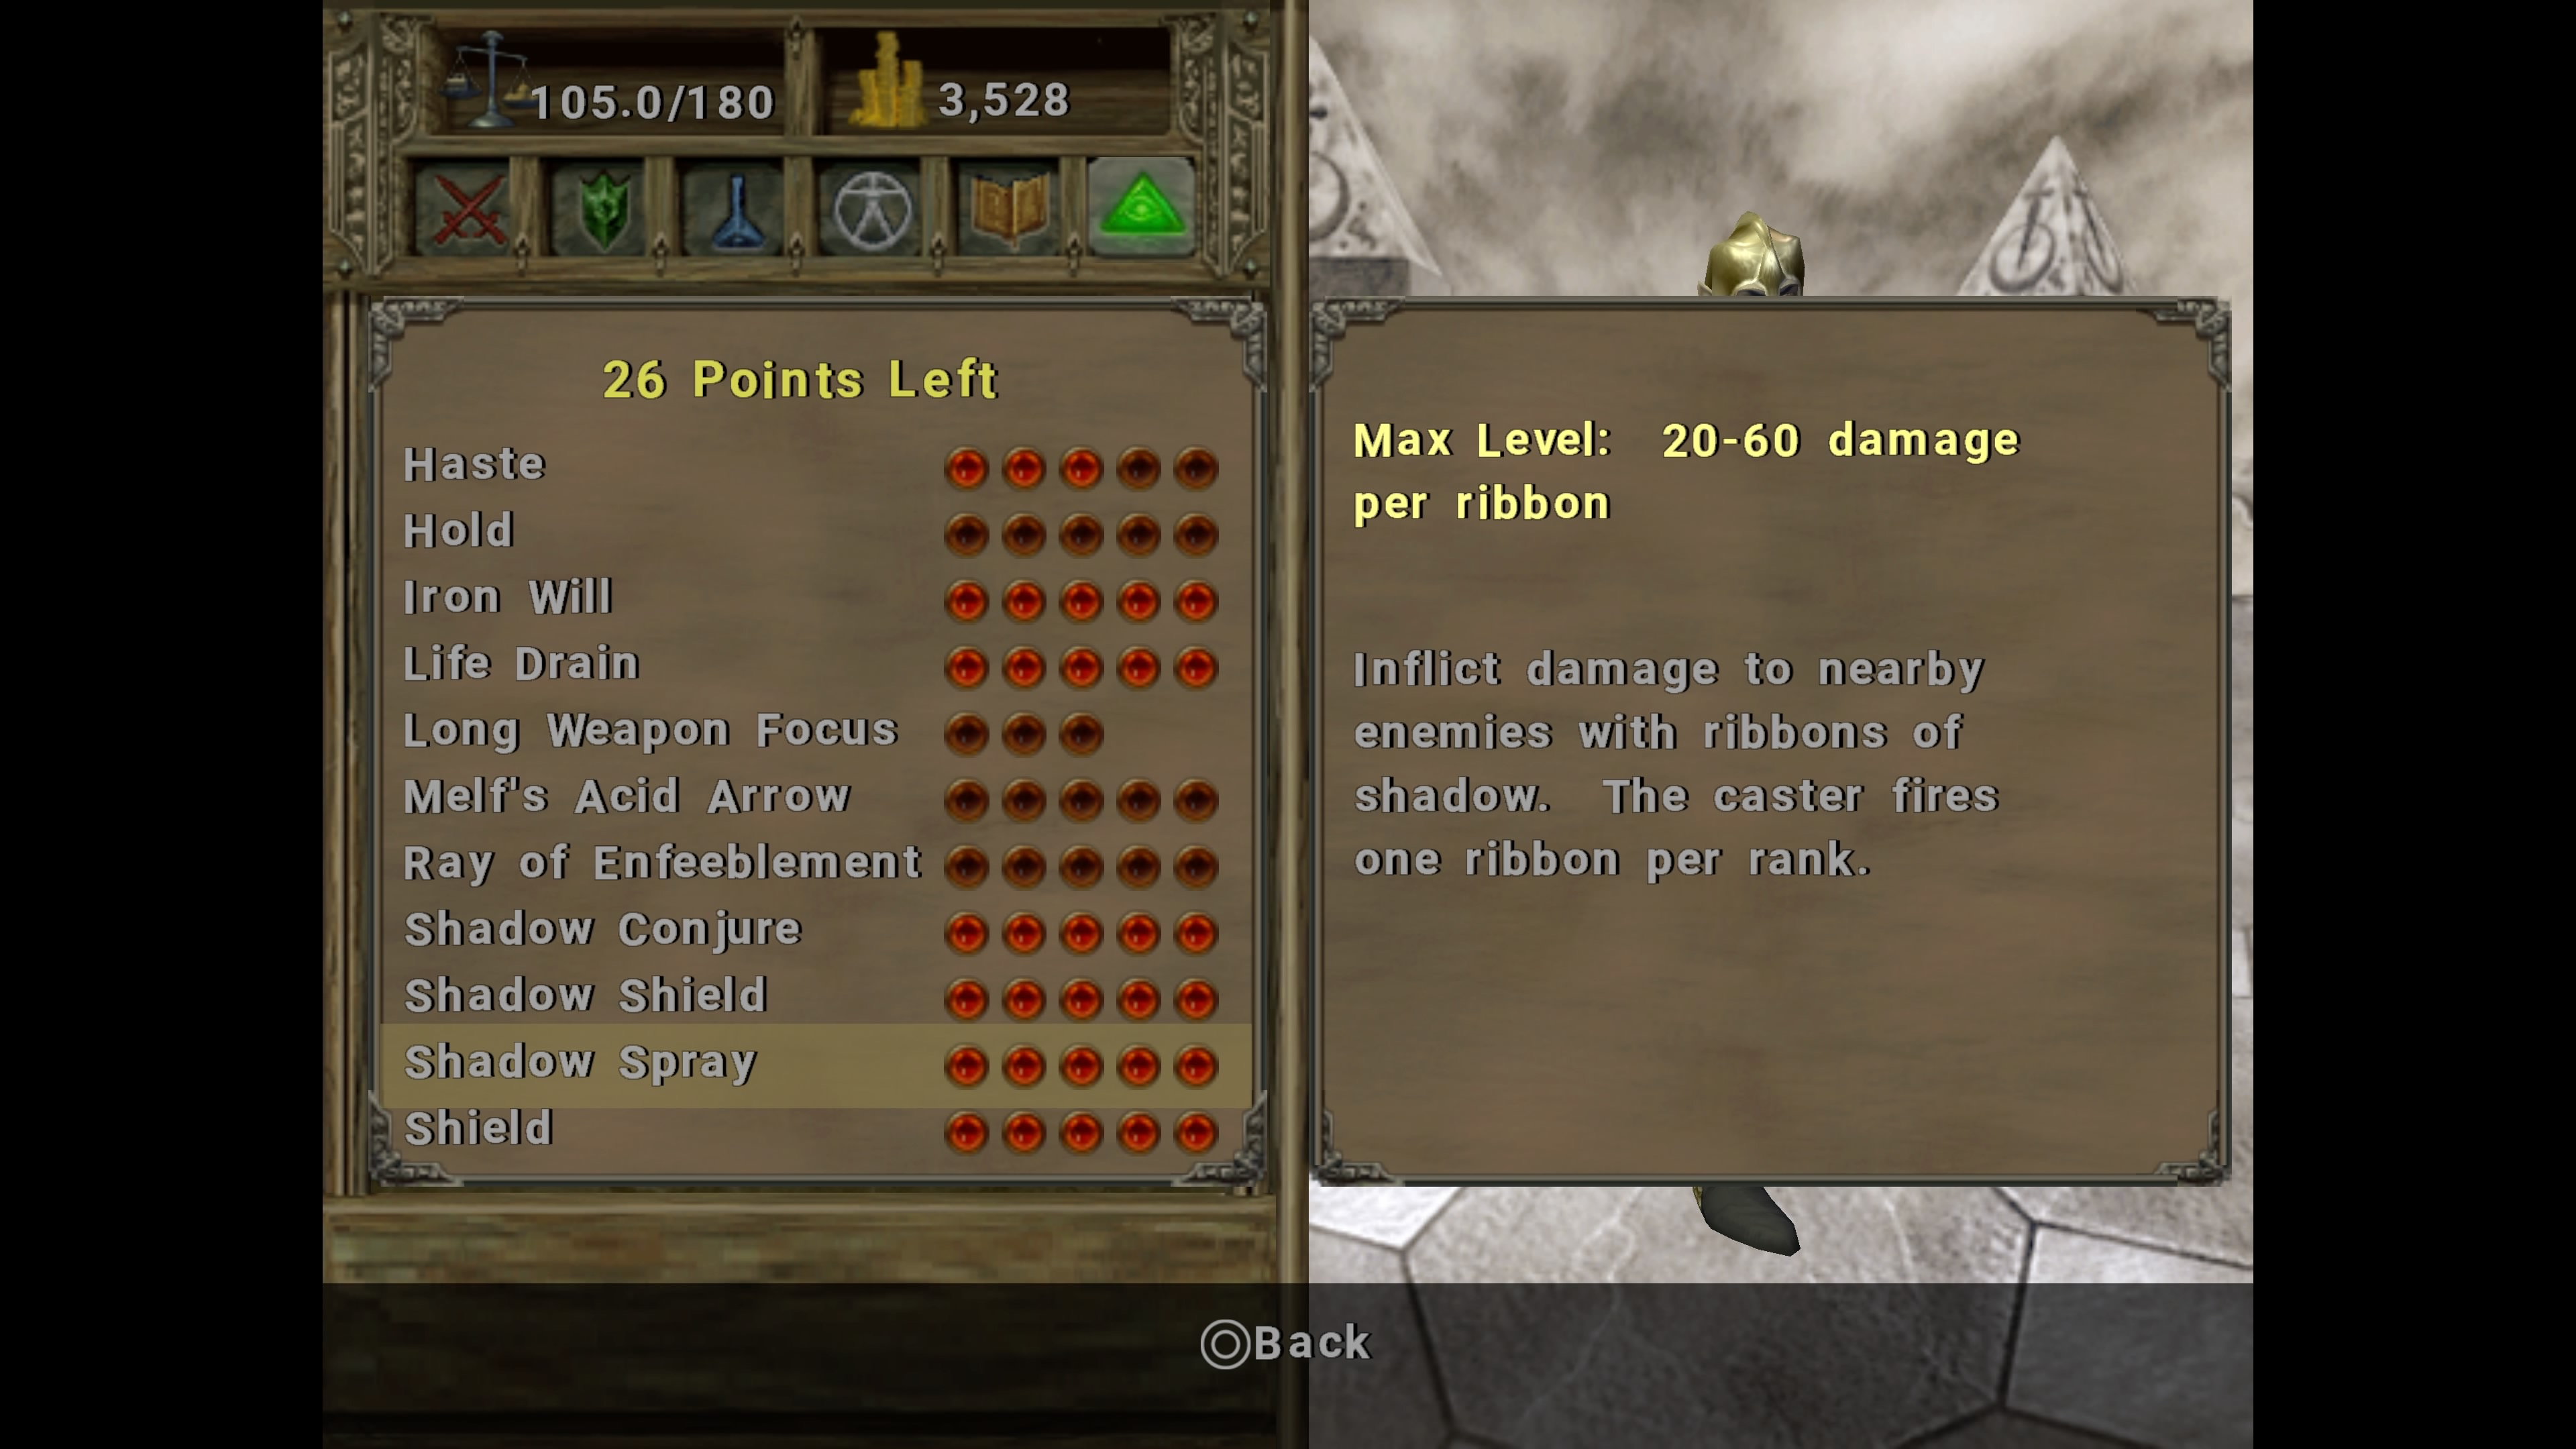
</div>

In [13]:
def shadow_spray(min_damage, max_damage, ribbons, trials= 10000):
    '''
    Calculate spell damage metrics for one-off spells towards
    early to late game optimization of skill points investment.
    
    Args:
        min_damage: minimum possible damage
        max_damage: maximum possible damage
        ribbons: number of ribbons the spell fires
        trials: default 10,000 iterations of the loop
    Returns:
        pd.DataFrame() containing range, average, median and standard deviation metrics
    '''
    max_possible_dmg = max_damage * ribbons
    damage_rolls = [random.randrange(min_damage, max_possible_dmg +1) for _ in range(trials)]
    spell_metrics = {
        'minimum': min_damage, # if only one ribbon hits at minimum damage
        'maximum': max_possible_dmg, # if all ribbons hit at maximum damage
        'range': max_possible_dmg - min_damage,
        'average': stats.mean(damage_rolls),
        'median': stats.median(damage_rolls),
        'std_dev': round(stats.stdev(damage_rolls), 2)
    }
    return pd.DataFrame(spell_metrics, index= [0])

In [14]:
shadow_spray(min_damage= 20, max_damage= 60, ribbons= 5)

,minimum,maximum,range,average,median,std_dev
0,20,300,280,161.1196,162.0,80.77


### Life Drain & Enervation

Life Drain & Enervation are both part of a different mechanism of spells, inflicting damage over time instead of a burst with a number of enemies affected by the spell determined by the spell's rank. Life Drain not only inflicts damage but also provides healing.

For the purpose of comparing damage output let's focus on analyzing enervation:
- damage 15-45 per half second
- affects 5 enemies

<div>
    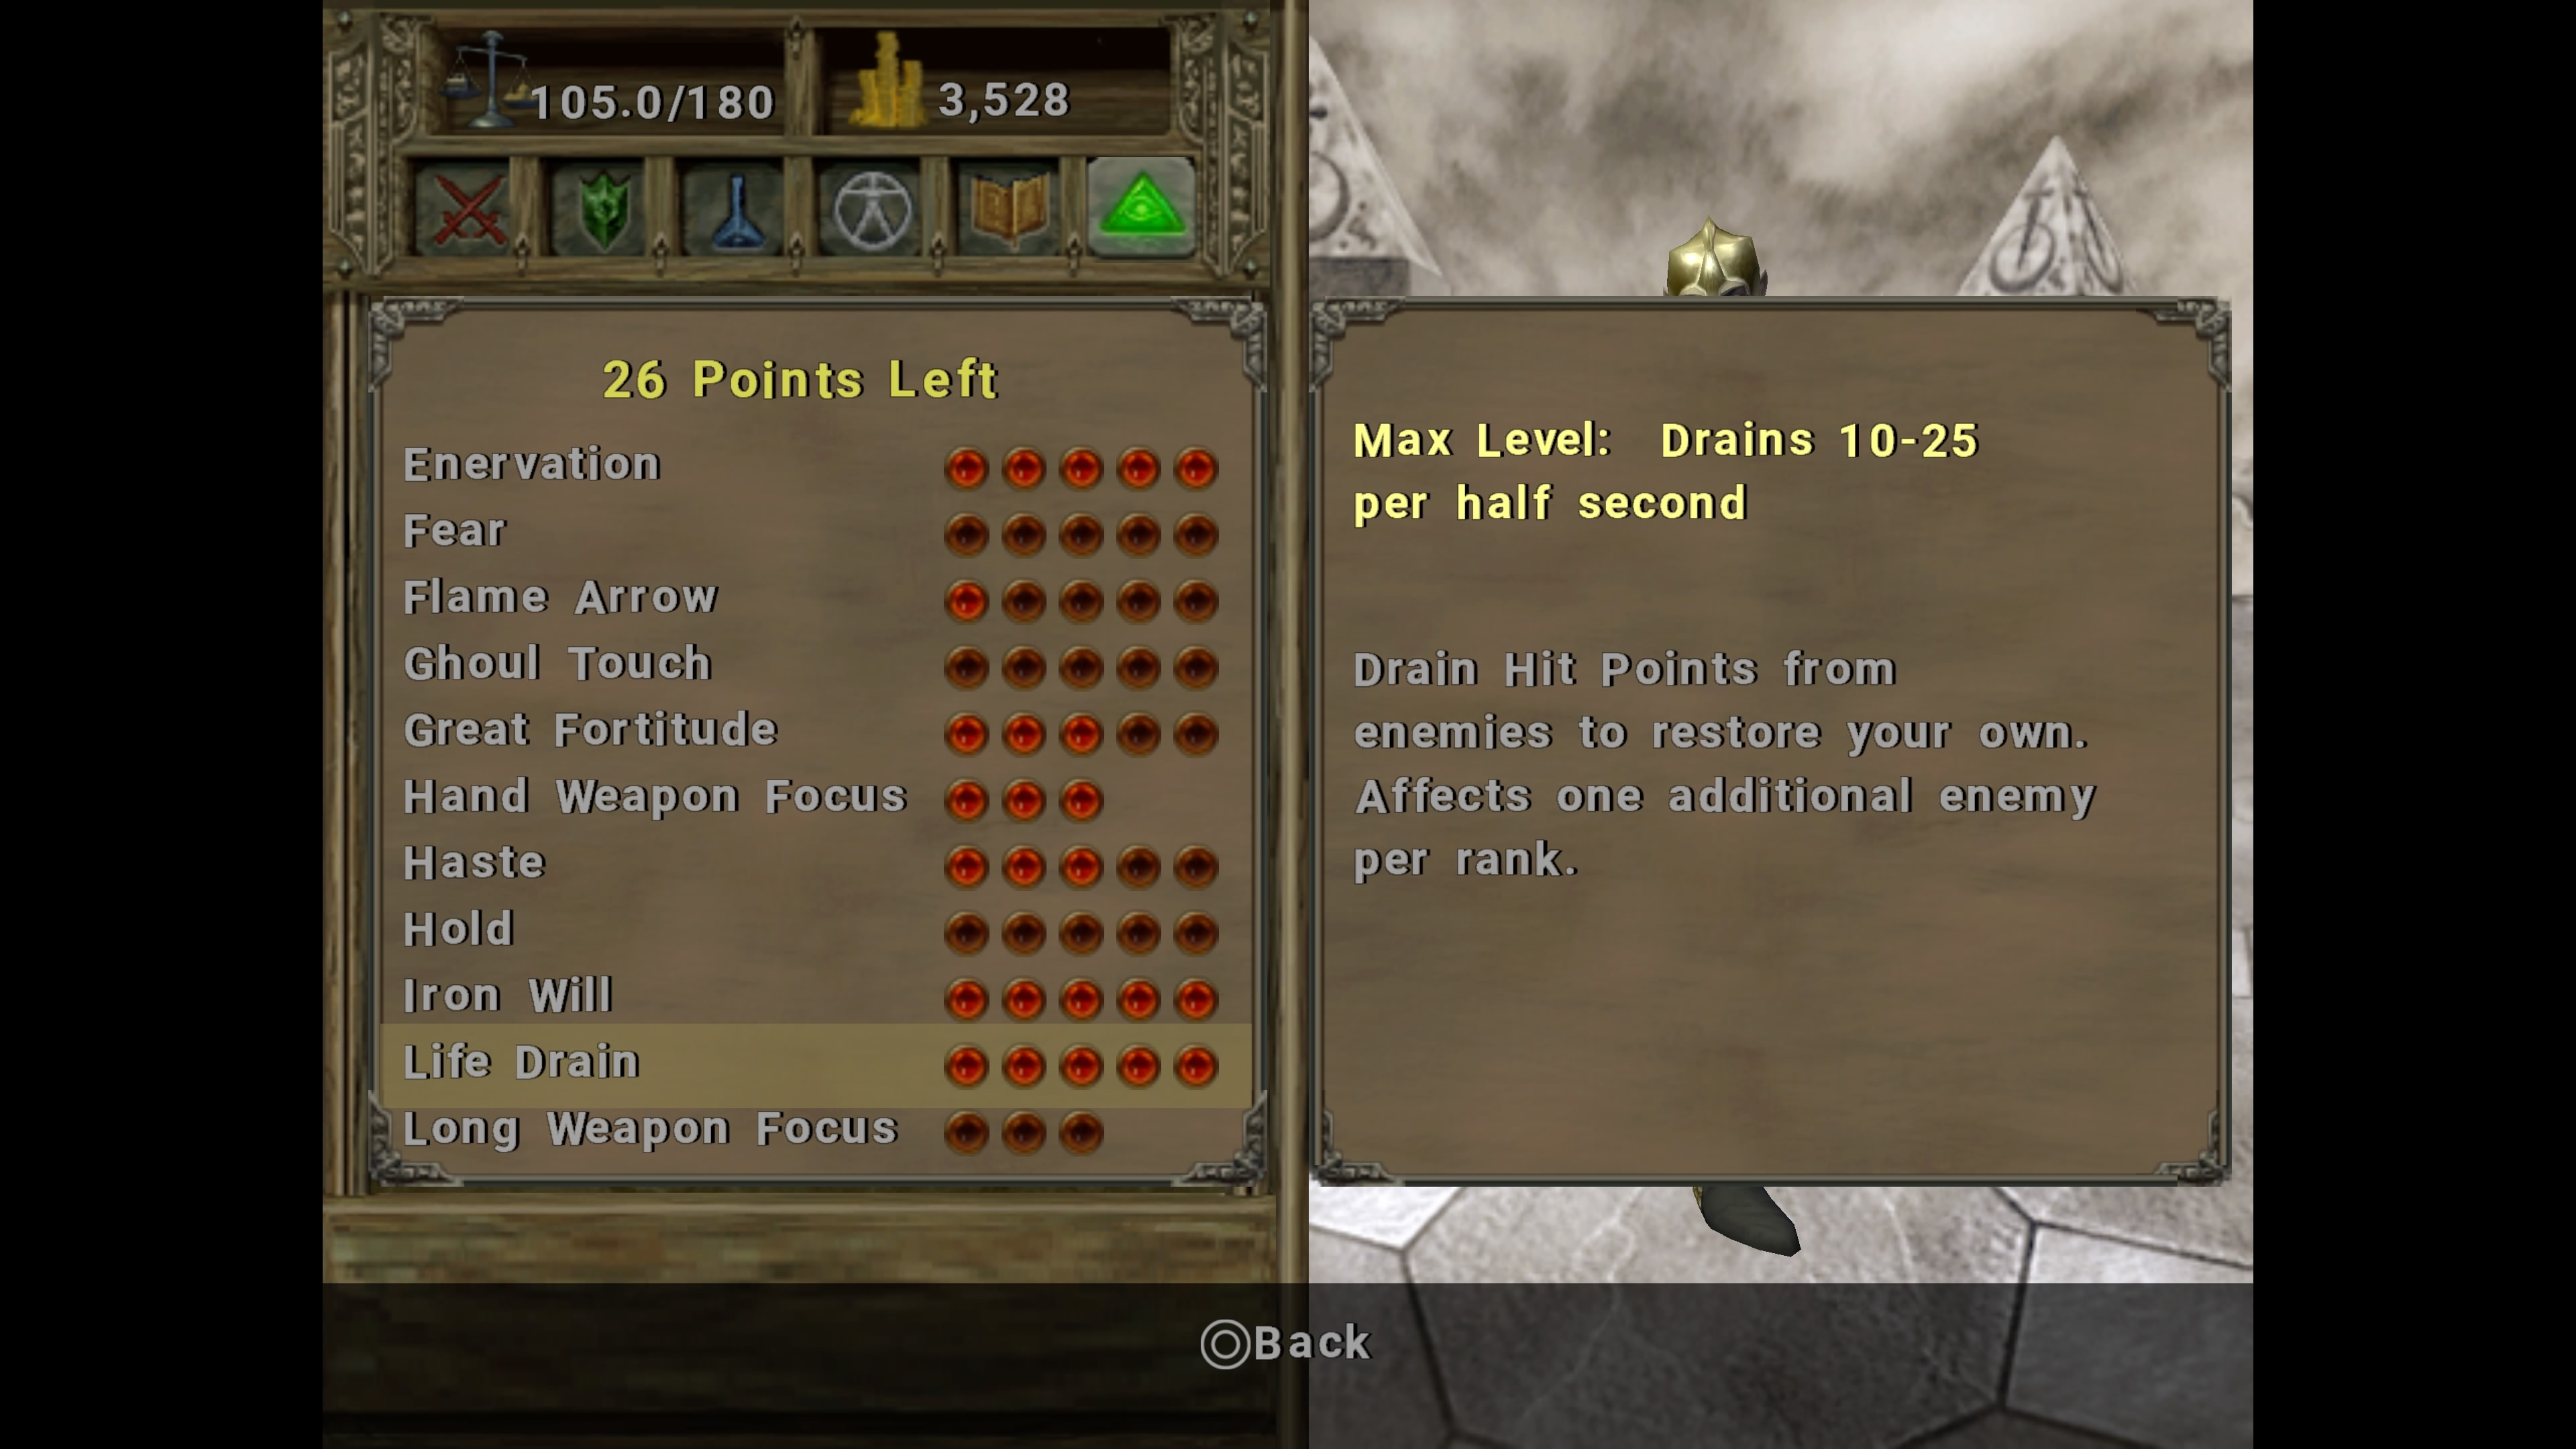
</div>
<div>
    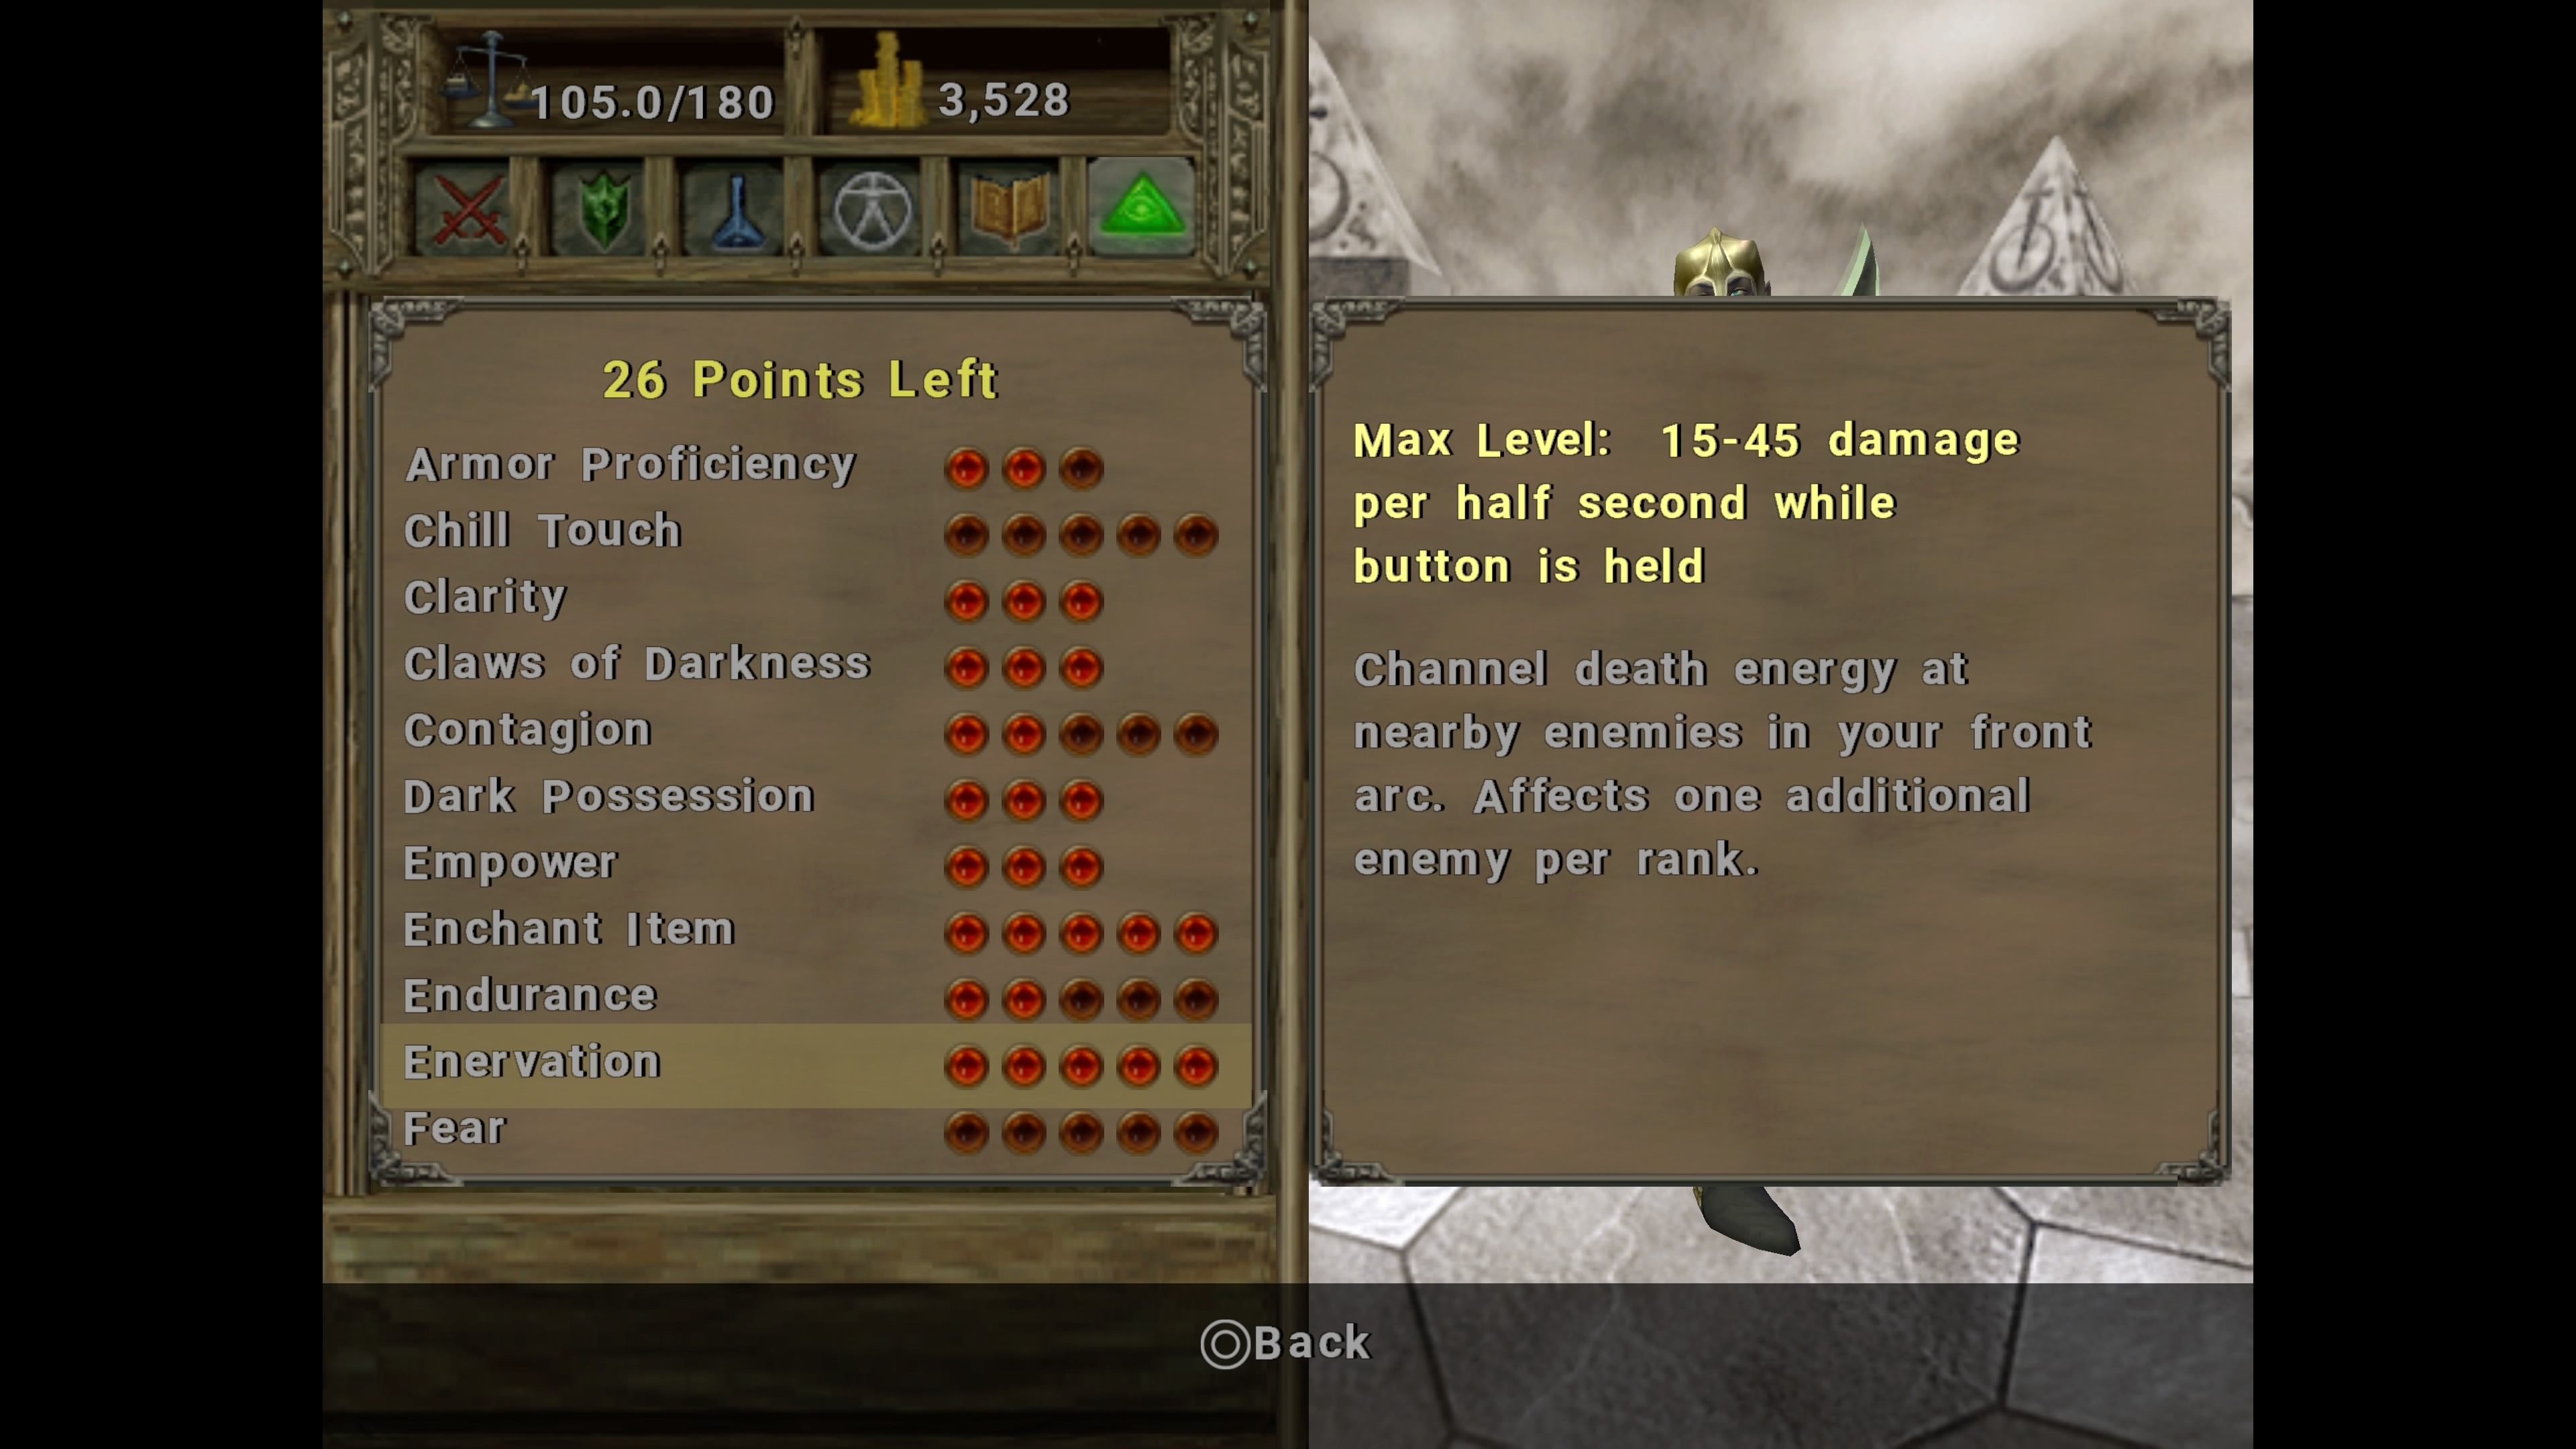
</div>

In [16]:
def enervation(min_damage, max_damage, enemies, max_duration, trials= 10000):
    '''
    Calculate spell damage metrics for held spells towards
    early to late game optimization of skill points investment.
    Assumption is made that the spell is not held for more than 10 seconds.
    
    Args:
        min_damage: minimum possible damage
        max_damage: maximum possible damage
        enemies: count of enemies affected while spell is in effect
        max_duration: how long the spell is held
    Returns:
        pd.DataFrame() containing range, average, median and standard deviation metrics
    '''
    tick_interval = 0.5
    ticks = int(max_duration / tick_interval)

    damage_per_cast = []

    for i in range(ticks):
        tick_dict = {}
        tick_dict['time held'] = f"{(i+1)/2} seconds"
        min_tick_damage = min_damage * i
        max_tick_damage = max_damage * i * enemies
        tick_dict['minimum'] = min_tick_damage
        tick_dict['maximum'] = max_tick_damage
        tick_dict['range'] = max_tick_damage - min_tick_damage
        damage_tick = [random.randrange(min_tick_damage, max_tick_damage +1) for _ in range(trials)]
        tick_dict['average'] = int(stats.mean(damage_tick))
        tick_dict['median'] = int(stats.median(damage_tick))
        tick_dict['std_dev'] = round(stats.stdev(damage_tick), 2)
        damage_per_cast.append(tick_dict)

    return pd.DataFrame(damage_per_cast)

In [17]:
enervation(min_damage= 15, max_damage= 45, max_duration= 10, enemies= 5)

,time held,minimum,maximum,range,average,median,std_dev
0,0.5 seconds,0,0,0,0,0,0.00
1,1.0 seconds,15,225,210,120,121,60.85
2,1.5 seconds,30,450,420,241,241,121.81
3,2.0 seconds,45,675,630,361,361,181.44
4,2.5 seconds,60,900,840,479,477,245.12
5,3.0 seconds,75,1125,1050,599,599,304.14
6,3.5 seconds,90,1350,1260,721,721,366.23
7,4.0 seconds,105,1575,1470,843,847,423.83
8,4.5 seconds,120,1800,1680,957,956,487.45
9,5.0 seconds,135,2025,1890,1070,1062,545.13
